Train shape: (300, 13)
Test shape : (200, 13)
Train columns (head): ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']
Detected LABEL_COL: label
y_train distribution: [150 150]
y_test  distribution: [100 100]
n_features (qubits): 12

Computing quantum kernel matrices...


C:\Users\shanmugam\AppData\Local\Temp\ipykernel_12408\1045013425.py:101: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=n_features, reps=2, entanglement="linear")


K_train: (300, 300) K_test: (200, 300)

================ QSVM BASELINE RESULTS ================
Accuracy : 0.7900
Precision: 0.7042
Recall   : 1.0000
F1-score : 0.8264
ROC-AUC  : 0.9158
PR-AUC   : 0.8776

Confusion Matrix:
 [[ 58  42]
 [  0 100]]


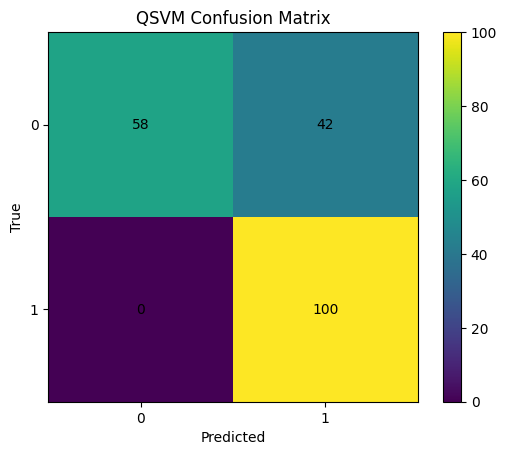

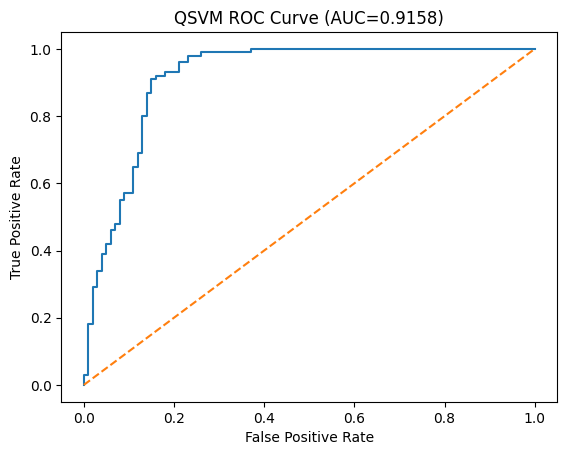

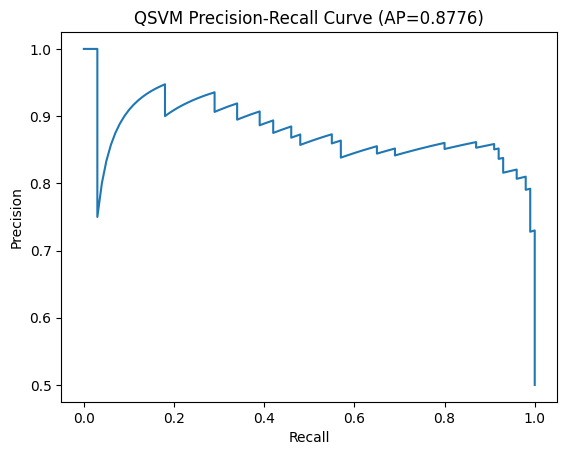

In [2]:
# ============================================================
# QSVM (QML Baseline)
# - Loads train/test PCA-12 CSVs
# - Standardize features
# - Quantum Kernel via ZZFeatureMap + Statevector fidelity
# - SVM with precomputed kernel
# - Full evaluation: Acc/Prec/Rec/F1/ROC-AUC/PR-AUC + CM
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit.circuit.library import ZZFeatureMap
from qiskit.quantum_info import Statevector

# ----------------------------
# Paths (your uploaded files)
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train columns (head):", list(train_df.columns[:10]))

# ----------------------------
# Auto-detect label column
# ----------------------------
def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: assume last column is label if it's binary-ish
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

# ----------------------------
# Split X/y
# ----------------------------
X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values

X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

# ----------------------------
# Ensure labels are 0/1
# ----------------------------
def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    # map smallest -> 0, largest -> 1 (binary)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution:", np.bincount(y_test))

# ----------------------------
# Standardize features
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ----------------------------
# Quantum kernel (Statevector fidelity)
# ----------------------------
# NOTE:
# - QSVM becomes slow if n_qubits (= n_features) is large.
# - For PCA-12, using 12 qubits is heavy but doable for baseline if dataset is not huge.
# - If too slow, reduce qubits by selecting fewer PCA dims (e.g., PCA-4/8).
n_features = X_train_s.shape[1]
print("n_features (qubits):", n_features)

feature_map = ZZFeatureMap(feature_dimension=n_features, reps=2, entanglement="linear")

def statevec_from_x(x):
    qc = feature_map.assign_parameters(x)
    return Statevector.from_instruction(qc)

def fidelity(sv1, sv2):
    # |<ψ|φ>|^2
    return np.abs(np.vdot(sv1.data, sv2.data))**2

def compute_kernel_matrix(XA, XB, cache_sv=True):
    # returns K of shape (len(XA), len(XB))
    XA = np.asarray(XA)
    XB = np.asarray(XB)

    if cache_sv:
        svA = [statevec_from_x(x) for x in XA]
        svB = [statevec_from_x(x) for x in XB]
        K = np.empty((len(svA), len(svB)), dtype=float)
        for i, a in enumerate(svA):
            for j, b in enumerate(svB):
                K[i, j] = fidelity(a, b)
        return K
    else:
        K = np.empty((len(XA), len(XB)), dtype=float)
        for i, xa in enumerate(XA):
            sva = statevec_from_x(xa)
            for j, xb in enumerate(XB):
                svb = statevec_from_x(xb)
                K[i, j] = fidelity(sva, svb)
        return K

print("\nComputing quantum kernel matrices...")
K_train = compute_kernel_matrix(X_train_s, X_train_s, cache_sv=True)
K_test  = compute_kernel_matrix(X_test_s,  X_train_s, cache_sv=True)

print("K_train:", K_train.shape, "K_test:", K_test.shape)

# ----------------------------
# Train QSVM (SVC precomputed)
# ----------------------------
qsvm = SVC(kernel="precomputed", C=1.0, probability=True, class_weight="balanced", random_state=42)
qsvm.fit(K_train, y_train)

# Predictions
y_pred = qsvm.predict(K_test)
y_proba = qsvm.predict_proba(K_test)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

# AUCs (only valid if both classes exist in y_test)
roc_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan
pr_auc  = average_precision_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan

print("\n================ QSVM BASELINE RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots: Confusion Matrix + ROC + PR
# ----------------------------
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("QSVM Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"QSVM ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"QSVM Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Using qiskit_aer.primitives.SamplerV2
Train shape: (300, 13)
Test shape : (200, 13)
Detected LABEL_COL: label
y_train distribution: [150 150]
y_test  distribution: [100 100]
n_features (qubits): 12

Training VQC...
Training done.

================ VQC RESULTS ================
Accuracy : 0.5650
Precision: 0.5747
Recall   : 0.5000
F1-score : 0.5348
ROC-AUC  : 0.6030
PR-AUC   : 0.6202

Confusion Matrix:
 [[63 37]
 [50 50]]


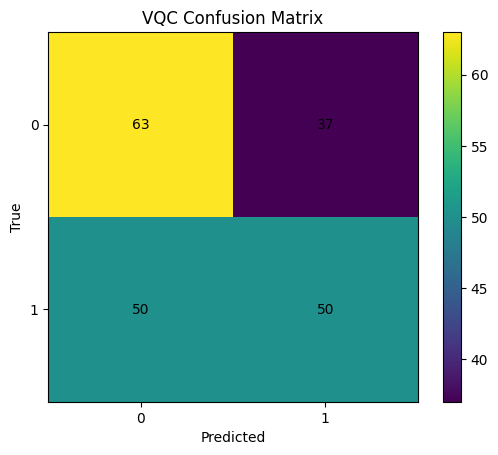

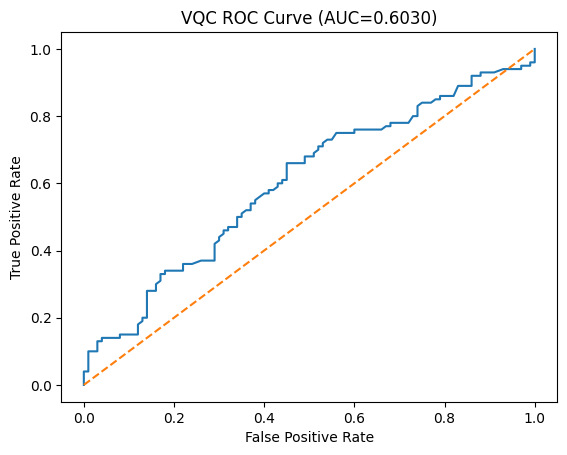

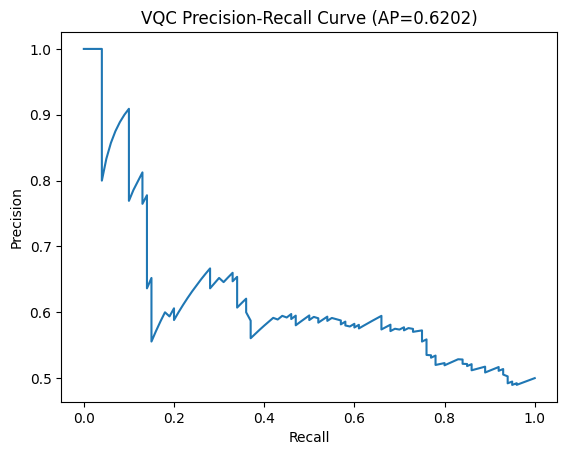

In [9]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC

# ✅ Aer Sampler (works reliably in your stack)
from qiskit_aer.primitives import SamplerV2 as AerSampler
sampler = AerSampler()
print("Using qiskit_aer.primitives.SamplerV2")

# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# ----------------------------
# Detect label column
# ----------------------------
def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution:", np.bincount(y_test))

# ----------------------------
# Scale
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_features = X_train_s.shape[1]
print("n_features (qubits):", n_features)

# ----------------------------
# ✅ IMPORTANT FIX: decompose circuits
# ----------------------------
feature_map = ZZFeatureMap(feature_dimension=n_features, reps=1, entanglement="linear").decompose()
ansatz      = RealAmplitudes(num_qubits=n_features, reps=1, entanglement="linear").decompose()

# Optimizer (baseline)
optimizer = COBYLA(maxiter=80)

loss_history = []
def callback(weights, loss):
    loss_history.append(loss)

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=sampler,
    callback=callback
)

print("\nTraining VQC...")
vqc.fit(X_train_s, y_train)
print("Training done.")

# ----------------------------
# Predict
# ----------------------------
y_pred = vqc.predict(X_test_s)

# predict_proba may not always be available; handle safely
y_proba = None
if hasattr(vqc, "predict_proba"):
    try:
        y_proba = vqc.predict_proba(X_test_s)[:, 1]
    except Exception:
        y_proba = None

# ----------------------------
# Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

roc_auc = np.nan
pr_auc  = np.nan
if y_proba is not None and len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)

print("\n================ VQC RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC  : (probabilities not available)")
print(f"PR-AUC   : {pr_auc:.4f}"  if not np.isnan(pr_auc)  else "PR-AUC   : (probabilities not available)")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots
# ----------------------------
if len(loss_history) > 0:
    plt.figure()
    plt.plot(loss_history)
    plt.title("VQC Training Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("VQC Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if y_proba is not None and len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"VQC ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"VQC Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

In [10]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit import QuantumCircuit

# ----------------------------
# Set number of qubits/features
# ----------------------------
n_features = 12   # PCA-12 => 12 qubits (change if PCA-8/PCA-4)

# ----------------------------
# Build circuits
# ----------------------------
feature_map = ZZFeatureMap(feature_dimension=n_features, reps=1, entanglement="linear").decompose()
ansatz      = RealAmplitudes(num_qubits=n_features, reps=1, entanglement="linear").decompose()

# Combine: feature_map then ansatz
vqc_circuit = QuantumCircuit(n_features)
vqc_circuit.compose(feature_map, inplace=True)
vqc_circuit.compose(ansatz, inplace=True)

# (Optional) add measurements if you want to sample bitstrings directly
# vqc_circuit.measure_all()

# ----------------------------
# Print circuit + properties
# ----------------------------
print("=== Feature Map Circuit ===")
print(feature_map.draw(output="text"))

print("\n=== Ansatz Circuit ===")
print(ansatz.draw(output="text"))

print("\n=== Full VQC Circuit (FeatureMap + Ansatz) ===")
print(vqc_circuit.draw(output="text"))

print("\n--- Circuit Stats ---")
print("Qubits:", vqc_circuit.num_qubits)
print("Parameters:", vqc_circuit.num_parameters)
print("Depth:", vqc_circuit.depth())
print("Size (ops):", vqc_circuit.size())
print("Op counts:", vqc_circuit.count_ops())

=== Feature Map Circuit ===
      ┌───┐┌───────────┐                                              »
 q_0: ┤ H ├┤ P(2*x[0]) ├───■──────────────────────────────────■───────»
      ├───┤├───────────┤ ┌─┴─┐┌────────────────────────────┐┌─┴─┐     »
 q_1: ┤ H ├┤ P(2*x[1]) ├─┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
      ├───┤├───────────┤ └───┘└────────────────────────────┘└───┘┌─┴─┐»
 q_2: ┤ H ├┤ P(2*x[2]) ├─────────────────────────────────────────┤ X ├»
      ├───┤├───────────┤                                         └───┘»
 q_3: ┤ H ├┤ P(2*x[3]) ├──────────────────────────────────────────────»
      ├───┤├───────────┤                                              »
 q_4: ┤ H ├┤ P(2*x[4]) ├──────────────────────────────────────────────»
      ├───┤├───────────┤                                              »
 q_5: ┤ H ├┤ P(2*x[5]) ├──────────────────────────────────────────────»
      ├───┤├───────────┤                                              »
 q_6: ┤ H ├┤ P(2*x[6]) ├────────────

In [11]:
# Make sure matplotlib backend works
import matplotlib.pyplot as plt

# Draw circuit as matplotlib figure
fig = vqc_circuit.draw(output="mpl")

# 🔹 Save location (change if needed)
save_path = r"C:\Users\shanmugam\Desktop\vqc_circuit.png"

# Save image
fig.savefig(save_path, dpi=300, bbox_inches="tight")

print("✅ Circuit image saved at:")
print(save_path)

✅ Circuit image saved at:
C:\Users\shanmugam\Desktop\vqc_circuit.png


In [12]:
import matplotlib.pyplot as plt

# Draw circuit (matplotlib figure)
fig = vqc_circuit.draw(output="mpl")

# 🔹 Make it LANDSCAPE (wide)
fig.set_size_inches(18, 6)   # width, height (adjust if needed)

# Save as PNG
save_path = r"C:\Users\shanmugam\Desktop\vqc_circuit_landscape.png"
fig.savefig(save_path, dpi=600, bbox_inches="tight")

print("✅ Landscape circuit saved at:")
print(save_path)

✅ Landscape circuit saved at:
C:\Users\shanmugam\Desktop\vqc_circuit_landscape.png


In [13]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit import QuantumCircuit

# 12 qubits (PCA-12)
n_features = 12

# Decompose to avoid Aer error
feature_map = ZZFeatureMap(
    feature_dimension=n_features,
    reps=1,
    entanglement="linear"
).decompose()

ansatz = RealAmplitudes(
    num_qubits=n_features,
    reps=1,
    entanglement="linear"
).decompose()

# Combine FeatureMap + Ansatz
vqc_circuit = QuantumCircuit(n_features)
vqc_circuit.compose(feature_map, inplace=True)
vqc_circuit.compose(ansatz, inplace=True)

In [14]:
import matplotlib.pyplot as plt
import os

# Draw circuit
fig = vqc_circuit.draw(
    output="mpl",
    fold=100   # prevents vertical splitting
)

# 🔥 Make LANDSCAPE
fig.set_size_inches(24, 6)   # wide layout

# Save in current folder
filename = "VQC_12qubit_landscape.png"
fig.savefig(filename, dpi=600, bbox_inches="tight")

print("✅ Saved at:", os.path.abspath(filename))

✅ Saved at: C:\Users\shanmugam\QUANTUM HACK\VQC_12qubit_landscape.png


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Train shape: (300, 13)
Test shape : (200, 13)
Detected LABEL_COL: label
y_train distribution: [150 150]
y_test  distribution : [100 100]
n_features (qubits): 12
Input params : 12
Weight params: 24
Circuit depth: 40  | size: 104
Using AerSamplerV2 with default_shots=1024

Training QNN...
Training done.

================ QNN RESULTS ================
Accuracy : 0.4550
Precision: 0.4494
Recall   : 0.4000
F1-score : 0.4233
ROC-AUC  : 0.4802
PR-AUC   : 0.4909

Confusion Matrix:
 [[51 49]
 [60 40]]


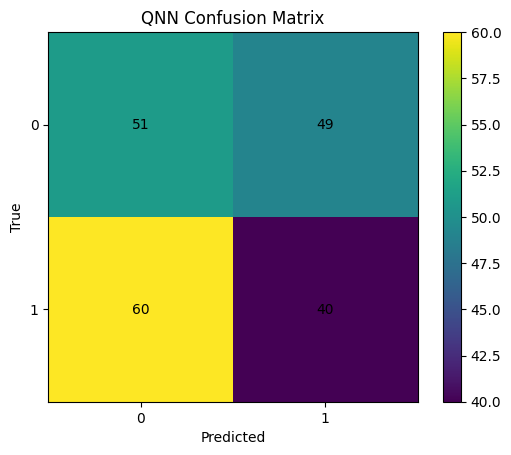

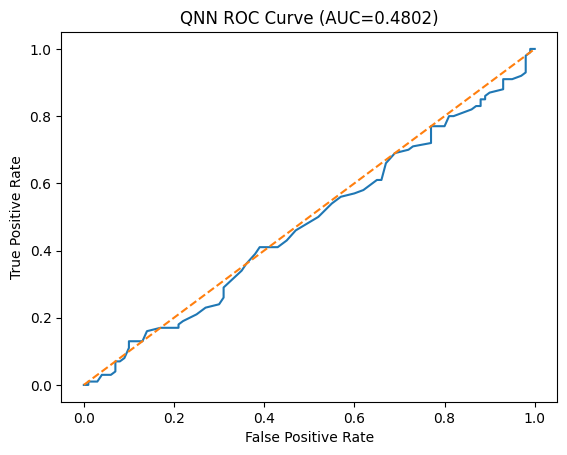

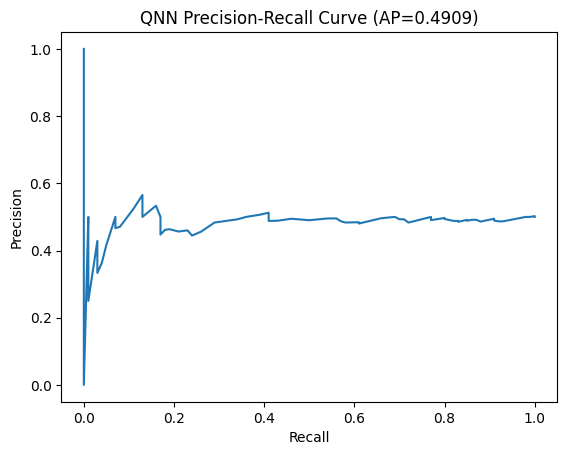

In [16]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA

from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier

# ✅ Aer SamplerV2 (correct for qiskit-aer 0.17.2)
from qiskit_aer.primitives import SamplerV2 as AerSampler


# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution :", np.bincount(y_test))

# ----------------------------
# Scale
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_features = X_train_s.shape[1]
print("n_features (qubits):", n_features)

# ----------------------------
# Build QNN circuit = FeatureMap(x) + Ansatz(θ) + Measurements
# IMPORTANT: decompose() avoids Aer 'unknown instruction' errors
# ----------------------------
feature_map = ZZFeatureMap(feature_dimension=n_features, reps=1, entanglement="linear").decompose()
ansatz      = RealAmplitudes(num_qubits=n_features, reps=1, entanglement="linear").decompose()

qc = QuantumCircuit(n_features)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)
qc.measure_all()

# Input parameters (x) and trainable parameters (θ)
input_params  = list(feature_map.parameters)
weight_params = list(ansatz.parameters)

print("Input params :", len(input_params))
print("Weight params:", len(weight_params))
print("Circuit depth:", qc.depth(), " | size:", qc.size())

# ----------------------------
# Interpret bitstring -> class
# Parity mapping: even parity => 0, odd parity => 1
# ----------------------------
def parity(bitstring_as_int: int) -> int:
    return bin(bitstring_as_int).count("1") % 2

output_shape = 2

# ----------------------------
# Sampler setup (✅ correct)
# ----------------------------
sampler = AerSampler(default_shots=1024)   # ✅ correct in your version
print("Using AerSamplerV2 with default_shots=1024")

# ----------------------------
# Build SamplerQNN
# ----------------------------
qnn = SamplerQNN(
    circuit=qc,
    input_params=input_params,
    weight_params=weight_params,
    interpret=parity,
    output_shape=output_shape,
    sampler=sampler
)

# ----------------------------
# Train classifier on QNN
# ----------------------------
optimizer = COBYLA(maxiter=60)  # reduce for speed; increase to 80/120 if needed

loss_history = []
def callback(weights, loss):
    loss_history.append(loss)

clf = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=optimizer,
    callback=callback
)

print("\nTraining QNN...")
clf.fit(X_train_s, y_train)
print("Training done.")

# ----------------------------
# Predict
# ----------------------------
y_pred = clf.predict(X_test_s)

y_proba = None
if hasattr(clf, "predict_proba"):
    try:
        y_proba = clf.predict_proba(X_test_s)[:, 1]
    except Exception:
        y_proba = None

# ----------------------------
# Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

roc_auc = np.nan
pr_auc  = np.nan
if y_proba is not None and len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)

print("\n================ QNN RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC  : (probabilities not available)")
print(f"PR-AUC   : {pr_auc:.4f}"  if not np.isnan(pr_auc)  else "PR-AUC   : (probabilities not available)")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots
# ----------------------------
if len(loss_history) > 0:
    plt.figure()
    plt.plot(loss_history)
    plt.title("QNN Training Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("QNN Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if y_proba is not None and len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"QNN ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"QNN Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

Detected LABEL_COL: label
Train shape: (300, 12)  Test shape: (200, 12)
y_train distribution: [150 150]
y_test  distribution: [100 100]
n_qubits (PCA dims): 12
QRFF circuit depth: 25 | size: 153
Quantum feature extraction time: train=4.333s, test=2.864s
Phi_train: (300, 128) Phi_test: (200, 128)

=== Q-RFF Results ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TrainTime(s),TestTime(s)
0,Q-RFF + LogReg,0.880,0.904255,0.85,0.876289,0.9595,0.953995,0.007414,0.000217
1,Q-RFF + MLP4,0.895,0.876190,0.92,0.897561,0.9629,0.957009,0.090275,0.000599



Best model: Q-RFF + MLP4


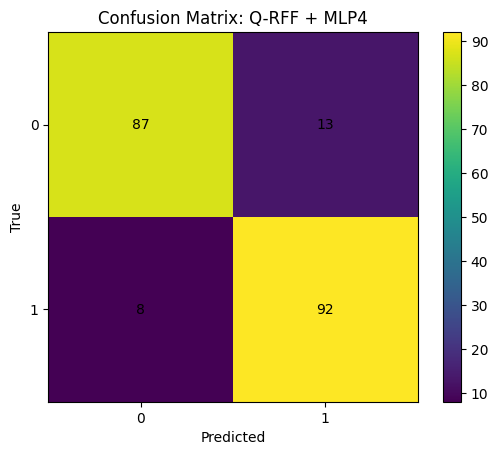

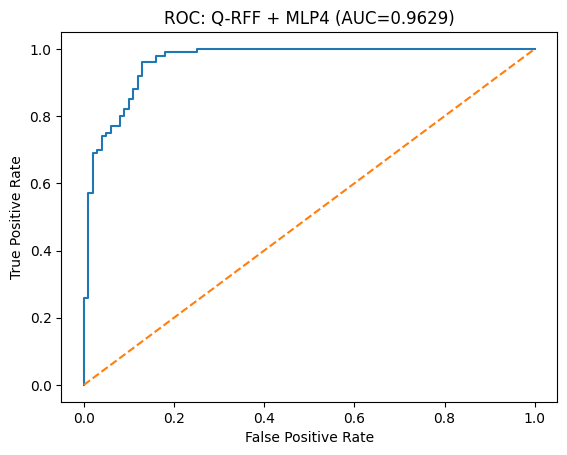

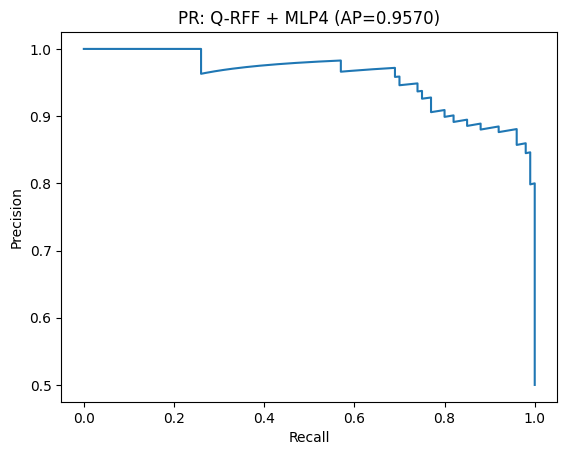

In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp

# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = train_df[LABEL_COL].values
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = test_df[LABEL_COL].values

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

y_train = make_binary_01(y_train)
y_test  = make_binary_01(y_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("y_train distribution:", np.bincount(y_train))
print("y_test  distribution:", np.bincount(y_test))

# ----------------------------
# Scale features
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_qubits = X_train_s.shape[1]
print("n_qubits (PCA dims):", n_qubits)

# ============================================================
# Q-RFF: Random Quantum Feature Map -> Expectation Features
# ------------------------------------------------------------
# We build ONE random parameterized circuit U(x) with fixed random weights.
# For each sample x, compute random features:
#   φ_k(x) = <ψ(x)| P_k |ψ(x)>, where P_k is a random Pauli operator.
# This acts like "quantum random Fourier features".
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

# ---- Hyperparameters (tune these to beat classical) ----
L_BLOCKS = 3        # number of data re-upload blocks (2~6 good)
M_FEATURES = 128    # number of random quantum features (64/128/256)
PAULI_SET = ["I", "Z", "X", "Y"]  # richer features than only Z
PAULI_PROBS = [0.35, 0.35, 0.15, 0.15]  # bias toward I/Z for stability

# Random weights used inside the encoding (fixed)
w1 = rng.normal(0, 1.0, size=n_qubits)
b1 = rng.uniform(-np.pi, np.pi, size=n_qubits)
w2 = rng.normal(0, 1.0, size=n_qubits)
b2 = rng.uniform(-np.pi, np.pi, size=n_qubits)

# Build parameter vector for input x
x = ParameterVector("x", n_qubits)

def build_qrff_circuit(nq, blocks):
    qc = QuantumCircuit(nq)

    # Start with Hadamards (helps spread)
    for i in range(nq):
        qc.h(i)

    # Data re-uploading blocks
    for _ in range(blocks):
        # Data encoding with fixed random weights (like random Fourier map)
        for i in range(nq):
            qc.ry(w1[i] * x[i] + b1[i], i)
            qc.rz(w2[i] * x[i] + b2[i], i)

        # Simple entanglement (linear chain)
        for i in range(nq - 1):
            qc.cx(i, i + 1)

        # Add small random single-qubit mixing (fixed angles)
        for i in range(nq):
            qc.rx(rng.uniform(-np.pi, np.pi), i)

    return qc

qrff_qc = build_qrff_circuit(n_qubits, L_BLOCKS)
print("QRFF circuit depth:", qrff_qc.depth(), "| size:", qrff_qc.size())

# ---- Create M random Pauli operators P_k ----
def random_pauli_string(nq):
    # build string like "IZX...Y" length nq
    return "".join(rng.choice(PAULI_SET, size=nq, p=PAULI_PROBS).tolist())

pauli_strings = [random_pauli_string(n_qubits) for _ in range(M_FEATURES)]
ops = [SparsePauliOp.from_list([(s, 1.0)]) for s in pauli_strings]

# ---- Feature extraction φ(x): expectation values of random Paulis ----
def quantum_features(X_scaled):
    feats = np.zeros((X_scaled.shape[0], M_FEATURES), dtype=np.float32)
    for idx, row in enumerate(X_scaled):
        bind = {x[i]: float(row[i]) for i in range(n_qubits)}
        qc_bound = qrff_qc.assign_parameters(bind, inplace=False)
        sv = Statevector.from_instruction(qc_bound)

        # expectation features
        for k, op in enumerate(ops):
            val = sv.expectation_value(op)
            feats[idx, k] = float(np.real(val))
    return feats

# ----------------------------
# Compute features (timed)
# ----------------------------
t0 = time.perf_counter()
Phi_train = quantum_features(X_train_s)
t1 = time.perf_counter()
Phi_test  = quantum_features(X_test_s)
t2 = time.perf_counter()

print(f"Quantum feature extraction time: train={t1-t0:.3f}s, test={t2-t1:.3f}s")
print("Phi_train:", Phi_train.shape, "Phi_test:", Phi_test.shape)

# Optional: scale quantum features (often helps)
qscaler = StandardScaler()
Phi_train_s = qscaler.fit_transform(Phi_train)
Phi_test_s  = qscaler.transform(Phi_test)

# ============================================================
# Classical heads: Linear + MLP4
# ============================================================

def eval_model(name, model, Xtr, ytr, Xte, yte):
    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    t1 = time.perf_counter()

    y_pred = model.predict(Xte)
    t2 = time.perf_counter()

    # probability if available
    y_proba = None
    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(Xte)[:, 1]
        except Exception:
            y_proba = None

    acc  = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, zero_division=0)
    rec  = recall_score(yte, y_pred, zero_division=0)
    f1   = f1_score(yte, y_pred, zero_division=0)

    roc_auc = np.nan
    pr_auc  = np.nan
    if y_proba is not None and len(np.unique(yte)) == 2:
        roc_auc = roc_auc_score(yte, y_proba)
        pr_auc  = average_precision_score(yte, y_proba)

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "TrainTime(s)": (t1 - t0),
        "TestTime(s)": (t2 - t1),
        "y_pred": y_pred,
        "y_proba": y_proba
    }

# ---- Heads ----
linear = LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs")
mlp4 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32, 16),   # "MLP4"
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    random_state=SEED
)

res_lin = eval_model("Q-RFF + LogReg", linear, Phi_train_s, y_train, Phi_test_s, y_test)
res_mlp = eval_model("Q-RFF + MLP4",   mlp4,   Phi_train_s, y_train, Phi_test_s, y_test)

results = pd.DataFrame([
    {k: v for k, v in res_lin.items() if k not in ["y_pred", "y_proba"]},
    {k: v for k, v in res_mlp.items() if k not in ["y_pred", "y_proba"]},
])

print("\n=== Q-RFF Results ===")
display(results)

# ----------------------------
# Plot confusion matrix + ROC/PR for best (by Accuracy)
# ----------------------------
best = res_mlp if res_mlp["Accuracy"] >= res_lin["Accuracy"] else res_lin
print("\nBest model:", best["Model"])

cm = confusion_matrix(y_test, best["y_pred"])
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix: {best['Model']}")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if best["y_proba"] is not None:
    fpr, tpr, _ = roc_curve(y_test, best["y_proba"])
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"ROC: {best['Model']} (AUC={best['ROC-AUC']:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, best["y_proba"])
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"PR: {best['Model']} (AP={best['PR-AUC']:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

Detected LABEL_COL: label
Train: (300, 12)  Test: (200, 12)
y_train: [150 150]  y_test: [100 100]
PCA dims / qubits: 12
QRFF circuit depth: 35 | size: 247
Quantum features time: train=7.315s, test=4.967s
Phi_train: (300, 256) Phi_test: (200, 256)
Fused feature shape: (300, 268)

=== Base Models (fused vs raw) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TrainTime(s),TestTime(s)
2,Baseline: CatBoost (raw PCA),0.950,0.968750,0.93,0.948980,0.9855,0.953667,1.595512,0.001264
0,Proposed: Q-RFF++ + CatBoost (fused),0.945,0.940594,0.95,0.945274,0.9862,0.985339,17.394386,0.016613
1,Proposed: Q-RFF++ + MLP4 (fused),0.915,0.867257,0.98,0.920188,0.9575,0.937275,0.171034,0.001358



=== FINAL COMPARISON (includes proposed stacking) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TrainTime(s),TestTime(s)
0,Baseline: CatBoost (raw PCA),0.950,0.968750,0.93,0.948980,0.9855,0.953667,1.595512,0.001264
1,Proposed: Q-RFF++ + CatBoost (fused),0.945,0.940594,0.95,0.945274,0.9862,0.985339,17.394386,0.016613
3,🔥 Proposed Final: Q-RFF++ Stacking (meta LR),0.940,0.931373,0.95,0.940594,0.9894,0.987982,0.000000,0.000000
2,Proposed: Q-RFF++ + MLP4 (fused),0.915,0.867257,0.98,0.920188,0.9575,0.937275,0.171034,0.001358



Best model: Baseline: CatBoost (raw PCA)


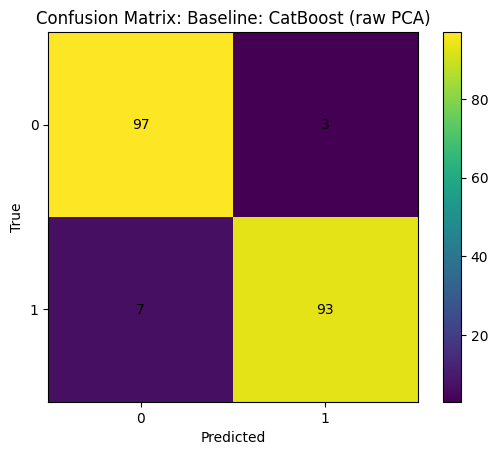

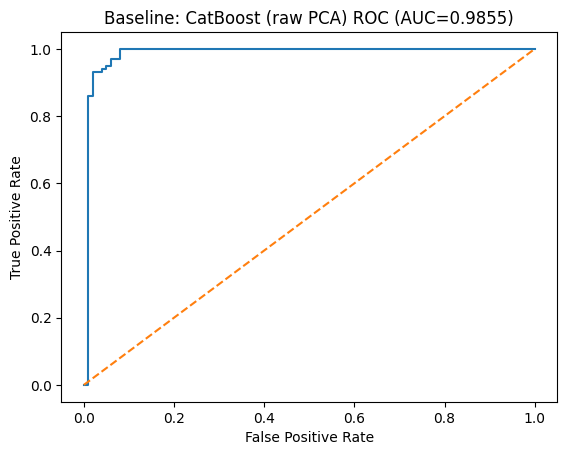

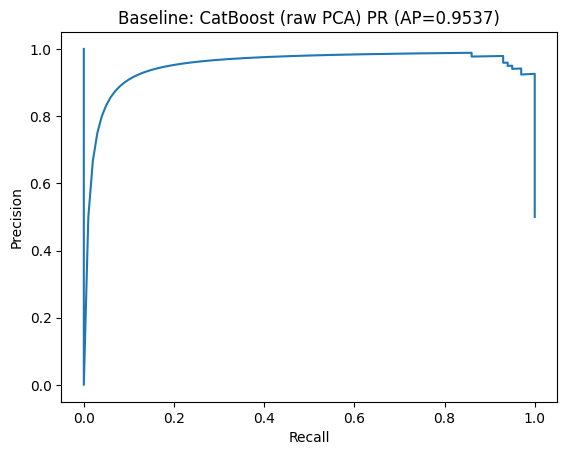

In [19]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from catboost import CatBoostClassifier

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp

# ----------------------------
# Utilities
# ----------------------------
def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

def eval_binary(name, y_true, y_pred, y_proba, train_time=0.0, test_time=0.0):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = np.nan
    pr_auc  = np.nan
    if y_proba is not None and len(np.unique(y_true)) == 2:
        roc_auc = roc_auc_score(y_true, y_proba)
        pr_auc  = average_precision_score(y_true, y_proba)
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "TrainTime(s)": train_time,
        "TestTime(s)": test_time,
    }

def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0,1], ["0","1"])
    plt.yticks([0,1], ["0","1"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    return cm

def plot_roc_pr(y_true, y_proba, title_prefix="Model"):
    if y_proba is None:
        print("No probabilities available for ROC/PR.")
        return
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{title_prefix} ROC (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"{title_prefix} PR (AP={ap:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = make_binary_01(train_df[LABEL_COL].values)
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = make_binary_01(test_df[LABEL_COL].values)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("y_train:", np.bincount(y_train), " y_test:", np.bincount(y_test))

# Standardize classical features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_qubits = X_train_s.shape[1]
print("PCA dims / qubits:", n_qubits)

# ============================================================
# Q-RFF Feature Extractor (fixed, no quantum training)
# ============================================================
SEED = 42
rng = np.random.default_rng(SEED)

# ---- Tune here (these are the knobs to beat classical) ----
L_BLOCKS   = 5        # 4–6 recommended
M_FEATURES = 256      # 256–512 recommended (dataset small so OK)

PAULI_SET   = ["I", "Z", "X", "Y"]
PAULI_PROBS = [0.30, 0.40, 0.15, 0.15]  # bias to I/Z for stability

# fixed random weights inside encoding (like random Fourier map)
w1 = rng.normal(0, 1.0, size=n_qubits)
b1 = rng.uniform(-np.pi, np.pi, size=n_qubits)
w2 = rng.normal(0, 1.0, size=n_qubits)
b2 = rng.uniform(-np.pi, np.pi, size=n_qubits)

x = ParameterVector("x", n_qubits)

def build_qrff_circuit(nq, blocks):
    qc = QuantumCircuit(nq)
    for i in range(nq):
        qc.h(i)
    for _ in range(blocks):
        for i in range(nq):
            qc.ry(w1[i] * x[i] + b1[i], i)
            qc.rz(w2[i] * x[i] + b2[i], i)
        for i in range(nq - 1):
            qc.cx(i, i + 1)
        for i in range(nq):
            qc.rx(rng.uniform(-np.pi, np.pi), i)
    return qc

qrff_qc = build_qrff_circuit(n_qubits, L_BLOCKS)
print("QRFF circuit depth:", qrff_qc.depth(), "| size:", qrff_qc.size())

def random_pauli_string(nq):
    return "".join(rng.choice(PAULI_SET, size=nq, p=PAULI_PROBS).tolist())

pauli_strings = [random_pauli_string(n_qubits) for _ in range(M_FEATURES)]
ops = [SparsePauliOp.from_list([(s, 1.0)]) for s in pauli_strings]

def quantum_features(X_scaled):
    feats = np.zeros((X_scaled.shape[0], M_FEATURES), dtype=np.float32)
    for idx, row in enumerate(X_scaled):
        bind = {x[i]: float(row[i]) for i in range(n_qubits)}
        sv = Statevector.from_instruction(qrff_qc.assign_parameters(bind, inplace=False))
        for k, op in enumerate(ops):
            feats[idx, k] = float(np.real(sv.expectation_value(op)))
    return feats

t0 = time.perf_counter()
Phi_train = quantum_features(X_train_s)
t1 = time.perf_counter()
Phi_test  = quantum_features(X_test_s)
t2 = time.perf_counter()
print(f"Quantum features time: train={t1-t0:.3f}s, test={t2-t1:.3f}s")
print("Phi_train:", Phi_train.shape, "Phi_test:", Phi_test.shape)

# scale quantum features
qscaler = StandardScaler()
Phi_train_s = qscaler.fit_transform(Phi_train)
Phi_test_s  = qscaler.transform(Phi_test)

# ============================================================
# Feature fusion (THIS is the proposed model core)
# ============================================================
Xf_train = np.hstack([X_train_s, Phi_train_s])   # fused
Xf_test  = np.hstack([X_test_s,  Phi_test_s])

print("Fused feature shape:", Xf_train.shape)

# ============================================================
# Base learners on fused features
# ============================================================
cat_fused = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=SEED
)

mlp4_fused = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),   # stronger than earlier
    activation="relu",
    alpha=1e-5,
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=True,
    random_state=SEED
)

# Optional strong baseline on raw only (for stacking diversity)
cat_raw = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=SEED + 1
)

# ============================================================
# Train + evaluate base models
# ============================================================
results = []

# CatBoost fused
t0 = time.perf_counter()
cat_fused.fit(Xf_train, y_train)
t1 = time.perf_counter()
proba = cat_fused.predict_proba(Xf_test)[:, 1]
pred  = (proba >= 0.5).astype(int)
t2 = time.perf_counter()
results.append(eval_binary("Proposed: Q-RFF++ + CatBoost (fused)", y_test, pred, proba, t1-t0, t2-t1))

# MLP4 fused
t0 = time.perf_counter()
mlp4_fused.fit(Xf_train, y_train)
t1 = time.perf_counter()
proba = mlp4_fused.predict_proba(Xf_test)[:, 1]
pred  = (proba >= 0.5).astype(int)
t2 = time.perf_counter()
results.append(eval_binary("Proposed: Q-RFF++ + MLP4 (fused)", y_test, pred, proba, t1-t0, t2-t1))

# CatBoost raw
t0 = time.perf_counter()
cat_raw.fit(X_train_s, y_train)
t1 = time.perf_counter()
proba = cat_raw.predict_proba(X_test_s)[:, 1]
pred  = (proba >= 0.5).astype(int)
t2 = time.perf_counter()
results.append(eval_binary("Baseline: CatBoost (raw PCA)", y_test, pred, proba, t1-t0, t2-t1))

base_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n=== Base Models (fused vs raw) ===")
display(base_df)

# ============================================================
# Stacking (meta-learner) using OOF predictions on train set
# ============================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Allocate OOF probas
oof_cat_fused = np.zeros(len(y_train))
oof_mlp_fused = np.zeros(len(y_train))
oof_cat_raw   = np.zeros(len(y_train))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_s, y_train), 1):
    Xtr_raw, Xva_raw = X_train_s[tr_idx], X_train_s[va_idx]
    Xtr_f,   Xva_f   = Xf_train[tr_idx], Xf_train[va_idx]
    ytr,     yva     = y_train[tr_idx], y_train[va_idx]

    # clone-like fresh models per fold
    m1 = CatBoostClassifier(iterations=600, depth=6, learning_rate=0.05,
                            loss_function="Logloss", verbose=False, random_seed=SEED+fold)
    m2 = MLPClassifier(hidden_layer_sizes=(256,128,64,32), activation="relu",
                       alpha=1e-5, learning_rate_init=1e-3, max_iter=600,
                       early_stopping=True, random_state=SEED+fold)
    m3 = CatBoostClassifier(iterations=600, depth=6, learning_rate=0.05,
                            loss_function="Logloss", verbose=False, random_seed=SEED+100+fold)

    m1.fit(Xtr_f, ytr)
    oof_cat_fused[va_idx] = m1.predict_proba(Xva_f)[:, 1]

    m2.fit(Xtr_f, ytr)
    oof_mlp_fused[va_idx] = m2.predict_proba(Xva_f)[:, 1]

    m3.fit(Xtr_raw, ytr)
    oof_cat_raw[va_idx] = m3.predict_proba(Xva_raw)[:, 1]

# Train meta model
meta_X_train = np.vstack([oof_cat_fused, oof_mlp_fused, oof_cat_raw]).T
meta = LogisticRegression(max_iter=5000)
meta.fit(meta_X_train, y_train)

# Test meta model
test_cat_fused = cat_fused.predict_proba(Xf_test)[:, 1]
test_mlp_fused = mlp4_fused.predict_proba(Xf_test)[:, 1]
test_cat_raw   = cat_raw.predict_proba(X_test_s)[:, 1]
meta_X_test = np.vstack([test_cat_fused, test_mlp_fused, test_cat_raw]).T

meta_proba = meta.predict_proba(meta_X_test)[:, 1]
meta_pred  = (meta_proba >= 0.5).astype(int)

stack_row = eval_binary("🔥 Proposed Final: Q-RFF++ Stacking (meta LR)", y_test, meta_pred, meta_proba)
final_df = pd.concat([base_df, pd.DataFrame([stack_row])], ignore_index=True).sort_values("Accuracy", ascending=False)

print("\n=== FINAL COMPARISON (includes proposed stacking) ===")
display(final_df)

# Plots for the best model
best_name = final_df.iloc[0]["Model"]
print("\nBest model:", best_name)

# Choose proba/pred for best row
if best_name == "🔥 Proposed Final: Q-RFF++ Stacking (meta LR)":
    best_pred, best_proba = meta_pred, meta_proba
elif "CatBoost (fused)" in best_name:
    best_proba = cat_fused.predict_proba(Xf_test)[:, 1]
    best_pred  = (best_proba >= 0.5).astype(int)
elif "MLP4 (fused)" in best_name:
    best_proba = mlp4_fused.predict_proba(Xf_test)[:, 1]
    best_pred  = (best_proba >= 0.5).astype(int)
else:
    best_proba = cat_raw.predict_proba(X_test_s)[:, 1]
    best_pred  = (best_proba >= 0.5).astype(int)

plot_cm(y_test, best_pred, title=f"Confusion Matrix: {best_name}")
plot_roc_pr(y_test, best_proba, title_prefix=best_name)

In [20]:
import numpy as np
import pandas as pd
import time

from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

from catboost import CatBoostClassifier


# ----------------------------
# Helpers
# ----------------------------
def eval_binary(name, y_true, y_pred, y_proba, train_time=0.0, test_time=0.0):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    roc = np.nan
    pr  = np.nan
    if y_proba is not None and len(np.unique(y_true)) == 2:
        roc = roc_auc_score(y_true, y_proba)
        pr  = average_precision_score(y_true, y_proba)

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "TrainTime(s)": train_time,
        "TestTime(s)": test_time
    }

def fit_predict_proba(model, Xtr, ytr, Xte):
    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    t1 = time.perf_counter()

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]
    else:
        proba = None

    pred = model.predict(Xte)
    t2 = time.perf_counter()
    return pred, proba, (t1 - t0), (t2 - t1)

# ----------------------------
# Safety checks
# ----------------------------
assert "X_train_s" in globals() and "Phi_train_s" in globals(), \
    "Run Q-RFF extraction first so X_train_s and Phi_train_s exist."
assert Phi_train_s.shape[1] == 256, "This code expects 256 quantum features (Phi_train_s)."

print("Raw PCA features :", X_train_s.shape)
print("Quantum features  :", Phi_train_s.shape)

# ----------------------------
# 1) Rank quantum features
# ----------------------------
SEED = 42
K_LIST = [16, 32, 64]  # you can add 128

rank_methods = {}

# (a) Mutual Information
mi = mutual_info_classif(Phi_train_s, y_train, random_state=SEED)
rank_methods["MI"] = np.argsort(mi)[::-1]

# (b) ANOVA F-score
fvals, _ = f_classif(Phi_train_s, y_train)
rank_methods["ANOVA"] = np.argsort(fvals)[::-1]

# (c) L1 Logistic weights (sparse)
l1 = LogisticRegression(
    penalty="l1", solver="liblinear", C=1.0,
    class_weight="balanced", max_iter=5000, random_state=SEED
)
l1.fit(Phi_train_s, y_train)
w = np.abs(l1.coef_).ravel()
rank_methods["L1"] = np.argsort(w)[::-1]

print("Ranking methods ready:", list(rank_methods.keys()))

# ----------------------------
# 2) Models to train on fused features
# ----------------------------
def make_catboost(seed):
    return CatBoostClassifier(
        iterations=1200,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        random_seed=seed,
        verbose=False
    )

def make_mlp4(seed):
    return MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation="relu",
        alpha=1e-5,
        learning_rate_init=1e-3,
        max_iter=800,
        early_stopping=True,
        random_state=seed
    )

# Baseline on RAW only (for comparison)
baseline_raw = make_catboost(SEED)
base_pred, base_proba, trt, tet = fit_predict_proba(baseline_raw, X_train_s, y_train, X_test_s)
rows = [eval_binary("Baseline: CatBoost (raw PCA)", y_test, base_pred, base_proba, trt, tet)]

# ----------------------------
# 3) Loop: method × top-k
# ----------------------------
for method_name, ranking in rank_methods.items():
    for k in K_LIST:
        idx = ranking[:k]

        # Select best quantum features
        Qtr = Phi_train_s[:, idx]
        Qte = Phi_test_s[:, idx]

        # Fuse: [raw PCA || selected quantum]
        Xf_tr = np.hstack([X_train_s, Qtr])
        Xf_te = np.hstack([X_test_s,  Qte])

        # ---- CatBoost fused ----
        model = make_catboost(SEED + k)
        pred, proba, trt, tet = fit_predict_proba(model, Xf_tr, y_train, Xf_te)
        rows.append(eval_binary(f"Proposed: {method_name}-Top{k} + CatBoost (fused)", y_test, pred, proba, trt, tet))

        # ---- MLP4 fused ----
        model2 = make_mlp4(SEED + k)
        pred2, proba2, trt2, tet2 = fit_predict_proba(model2, Xf_tr, y_train, Xf_te)
        rows.append(eval_binary(f"Proposed: {method_name}-Top{k} + MLP4 (fused)", y_test, pred2, proba2, trt2, tet2))

# ----------------------------
# Show results
# ----------------------------
res_df = pd.DataFrame(rows).sort_values(["Accuracy", "ROC-AUC"], ascending=False)
print("\n=== Quantum Feature Selection + Fusion Results ===")
display(res_df)

Raw PCA features : (300, 12)
Quantum features  : (300, 256)


C:\Users\shanmugam\anaconda3\envs\shanqml\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\shanmugam\anaconda3\envs\shanqml\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Ranking methods ready: ['MI', 'ANOVA', 'L1']

=== Quantum Feature Selection + Fusion Results ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TrainTime(s),TestTime(s)
3,Proposed: MI-Top32 + CatBoost (fused),0.955,0.950495,0.96,0.955224,0.9853,0.984018,4.033442,0.002231
13,Proposed: L1-Top16 + CatBoost (fused),0.955,0.950495,0.96,0.955224,0.9813,0.975564,3.269820,0.002025
17,Proposed: L1-Top64 + CatBoost (fused),0.950,0.941176,0.96,0.950495,0.9892,0.988834,7.027008,0.002737
5,Proposed: MI-Top64 + CatBoost (fused),0.950,0.941176,0.96,0.950495,0.9845,0.983221,6.829451,0.002465
15,Proposed: L1-Top32 + CatBoost (fused),0.950,0.941176,0.96,0.950495,0.9841,0.979779,4.350355,0.002485
16,Proposed: L1-Top32 + MLP4 (fused),0.950,0.916667,0.99,0.951923,0.9797,0.972428,0.106277,0.001834
0,Baseline: CatBoost (raw PCA),0.945,0.968421,0.92,0.943590,0.9861,0.964809,1.898006,0.002274
7,Proposed: ANOVA-Top16 + CatBoost (fused),0.945,0.940594,0.95,0.945274,0.9842,0.982404,3.089013,0.002107
9,Proposed: ANOVA-Top32 + CatBoost (fused),0.940,0.940000,0.94,0.940000,0.9883,0.987550,4.150987,0.002236
1,Proposed: MI-Top16 + CatBoost (fused),0.940,0.940000,0.94,0.940000,0.9876,0.986812,3.122073,0.002262


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Detected LABEL_COL: label
Train: (300, 12)  Test: (200, 12)
y_train: [150 150]  y_test: [100 100]
n_qubits: 12
Circuit depth: 66 | size: 264 | trainable params: 96
Using AerSamplerV2(default_shots=512)

Training Deep Re-upload QNN...


C:\Users\shanmugam\anaconda3\envs\shanqml\Lib\site-packages\scipy\_lib\pyprima\common\preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 98
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


Training done.

================ Deep QNN (Re-upload) RESULTS ================
Accuracy : 0.5350
Precision: 0.5393
Recall   : 0.4800
F1-score : 0.5079
ROC-AUC  : 0.5662
PR-AUC   : 0.5755

Confusion Matrix:
 [[59 41]
 [52 48]]


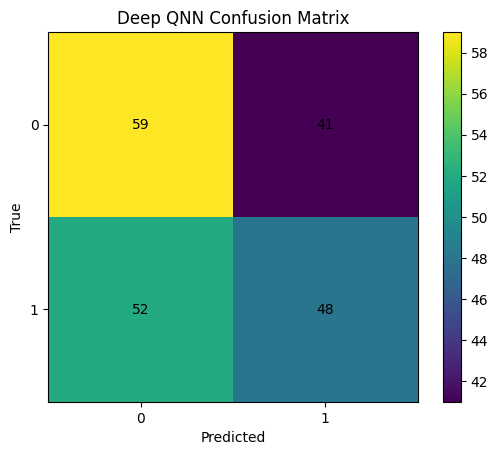

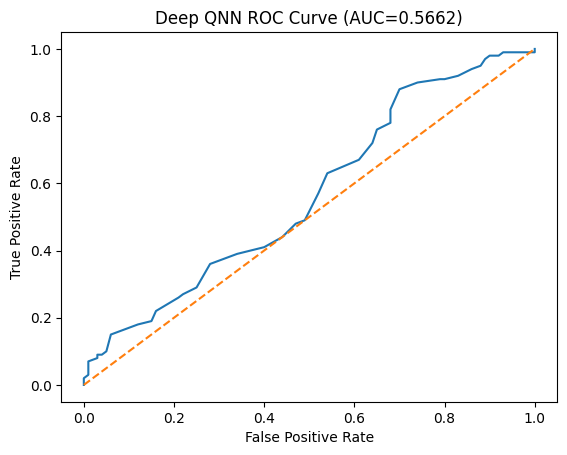

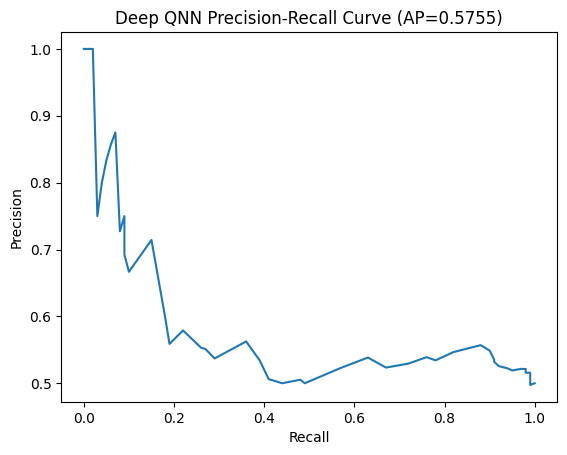

In [21]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_algorithms.optimizers import COBYLA

from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier

# ✅ correct for your versions
from qiskit_aer.primitives import SamplerV2 as AerSampler

# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

LABEL_COL = detect_label_col(train_df)
print("Detected LABEL_COL:", LABEL_COL)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(float)
y_train = make_binary_01(train_df[LABEL_COL].values)
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(float)
y_test  = make_binary_01(test_df[LABEL_COL].values)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("y_train:", np.bincount(y_train), " y_test:", np.bincount(y_test))

# ----------------------------
# Scale
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

n_qubits = X_train_s.shape[1]
print("n_qubits:", n_qubits)

# ============================================================
# Deep Data Re-uploading QNN Circuit
# ============================================================
# Hyperparameters (tune for accuracy/speed)
L_BLOCKS = 4          # 3..6 (deepness). Start 4.
SHOTS = 512           # 256..2048 (more shots => more stable, slower)
MAXITER = 80          # 60..200 (more iters => better, slower)

# Input parameters
x = ParameterVector("x", n_qubits)

# Trainable parameters: per block, per qubit we use 2 angles (ry, rz)
# Total = L_BLOCKS * n_qubits * 2
theta = ParameterVector("θ", L_BLOCKS * n_qubits * 2)

def build_deep_reupload_qnn(nq, blocks, x_params, w_params):
    qc = QuantumCircuit(nq)

    # small warm-start layer (optional)
    for i in range(nq):
        qc.h(i)

    w_idx = 0
    for b in range(blocks):
        # --- Data re-upload: encode x again and again ---
        for i in range(nq):
            qc.ry(x_params[i], i)
            qc.rz(x_params[i], i)

        # --- Trainable layer ---
        for i in range(nq):
            qc.ry(w_params[w_idx], i); w_idx += 1
            qc.rz(w_params[w_idx], i); w_idx += 1

        # --- Entanglement ---
        for i in range(nq - 1):
            qc.cx(i, i + 1)
        # ring entanglement (helps) - comment if too slow
        qc.cx(nq - 1, 0)

    qc.measure_all()
    return qc

qc = build_deep_reupload_qnn(n_qubits, L_BLOCKS, x, theta)

print("Circuit depth:", qc.depth(), "| size:", qc.size(), "| trainable params:", len(theta))

# ----------------------------
# Interpret bitstring -> class (parity)
# ----------------------------
def parity(bitstring_as_int: int) -> int:
    return bin(bitstring_as_int).count("1") % 2

# Sampler (correct usage for your environment)
sampler = AerSampler(default_shots=SHOTS)
print(f"Using AerSamplerV2(default_shots={SHOTS})")

qnn = SamplerQNN(
    circuit=qc,
    input_params=list(x),
    weight_params=list(theta),
    interpret=parity,
    output_shape=2,
    sampler=sampler
)

# ----------------------------
# Train
# ----------------------------
optimizer = COBYLA(maxiter=MAXITER)

loss_history = []
def callback(weights, loss):
    loss_history.append(loss)

clf = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=optimizer,
    callback=callback
)

print("\nTraining Deep Re-upload QNN...")
clf.fit(X_train_s, y_train)
print("Training done.")

# ----------------------------
# Predict + metrics
# ----------------------------
y_pred = clf.predict(X_test_s)

y_proba = None
if hasattr(clf, "predict_proba"):
    try:
        y_proba = clf.predict_proba(X_test_s)[:, 1]
    except Exception:
        y_proba = None

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

roc_auc = np.nan
pr_auc  = np.nan
if y_proba is not None and len(np.unique(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)

print("\n================ Deep QNN (Re-upload) RESULTS ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC  : (probabilities not available)")
print(f"PR-AUC   : {pr_auc:.4f}"  if not np.isnan(pr_auc)  else "PR-AUC   : (probabilities not available)")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# Plots
# ----------------------------
if len(loss_history) > 0:
    plt.figure()
    plt.plot(loss_history)
    plt.title("Deep QNN Training Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Deep QNN Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

if y_proba is not None and len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"Deep QNN ROC Curve (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    pr, rc, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rc, pr)
    plt.title(f"Deep QNN Precision-Recall Curve (AP={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

from catboost import CatBoostClassifier

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp

# ----------------------------
# Load data
# ----------------------------
TRAIN_PATH = "train_pca12.csv"
TEST_PATH  = "test_pca12.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

def detect_label_col(df):
    candidates = ["label", "Label", "y", "Y", "target", "Target", "class", "Class"]
    for c in candidates:
        if c in df.columns:
            return c
    last = df.columns[-1]
    if df[last].nunique() <= 10:
        return last
    raise ValueError("Could not detect label column. Rename label column to 'label'.")

def make_binary_01(y):
    y = np.array(y)
    uniq = np.unique(y)
    if set(uniq.tolist()) <= {0, 1}:
        return y.astype(int)
    if len(uniq) == 2:
        m = {uniq[0]: 0, uniq[1]: 1}
        return np.array([m[v] for v in y], dtype=int)
    raise ValueError(f"Labels are not binary. Unique labels: {uniq}")

LABEL_COL = detect_label_col(train_df)

X_train = train_df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_train = make_binary_01(train_df[LABEL_COL].values)
X_test  = test_df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_test  = make_binary_01(test_df[LABEL_COL].values)

print("Detected LABEL_COL:", LABEL_COL)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("y_train:", np.bincount(y_train), " y_test:", np.bincount(y_test))

# ----------------------------
# Scale raw PCA
# ----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_qubits = X_train_s.shape[1]
print("PCA dims / qubits:", n_qubits)

# ============================================================
# Multi-Map Q-RFF Ensemble (FAST SETTINGS)
# ============================================================
SEED = 42
rng_master = np.random.default_rng(SEED)

E_MAPS = 5           # 5 is a good start; try 7 or 9 if time permits
M_PER_MAP = 64       # quantum features per map (fast); try 96 if needed
TOPK = 16            # keep top features per map
L_BLOCKS = 3         # 2..4; 3 is a good speed/quality tradeoff

# Pauli set: keep it "light" for speed/stability
PAULI_SET   = ["I", "Z", "X"]         # avoid too much Y (slower/noisier)
PAULI_PROBS = [0.35, 0.45, 0.20]

x = ParameterVector("x", n_qubits)

def build_map_circuit(rng_local):
    """One random re-upload circuit with fixed random weights."""
    w1 = rng_local.normal(0, 1.0, size=n_qubits)
    b1 = rng_local.uniform(-np.pi, np.pi, size=n_qubits)
    w2 = rng_local.normal(0, 1.0, size=n_qubits)
    b2 = rng_local.uniform(-np.pi, np.pi, size=n_qubits)

    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.h(i)

    for _ in range(L_BLOCKS):
        for i in range(n_qubits):
            qc.ry(w1[i] * x[i] + b1[i], i)
            qc.rz(w2[i] * x[i] + b2[i], i)
        # linear entanglement
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        # light mixing
        for i in range(n_qubits):
            qc.rx(rng_local.uniform(-np.pi, np.pi), i)

    return qc

def random_pauli_ops(rng_local, m):
    """Create m random Pauli operators as SparsePauliOp."""
    def one_string():
        return "".join(rng_local.choice(PAULI_SET, size=n_qubits, p=PAULI_PROBS).tolist())
    strings = [one_string() for _ in range(m)]
    ops = [SparsePauliOp.from_list([(s, 1.0)]) for s in strings]
    return ops

def extract_features_for_map(qc, ops, X_scaled):
    """Compute expectation features for each sample (statevector, fast enough for 12q, N=300)."""
    N = X_scaled.shape[0]
    M = len(ops)
    feats = np.empty((N, M), dtype=np.float32)

    # pre-build parameter dict keys once
    for idx in range(N):
        bind = {x[i]: float(X_scaled[idx, i]) for i in range(n_qubits)}
        sv = Statevector.from_instruction(qc.assign_parameters(bind, inplace=False))
        # compute all features
        for k, op in enumerate(ops):
            feats[idx, k] = float(np.real(sv.expectation_value(op)))
    return feats

# ----------------------------
# Build E maps, extract features, select TopK per map
# ----------------------------
t0 = time.perf_counter()

selected_train_parts = []
selected_test_parts  = []
selected_info = []  # (map_id, selected_indices_in_map)

for m_id in range(E_MAPS):
    # independent RNG per map
    rng_local = np.random.default_rng(rng_master.integers(0, 2**32 - 1))

    qc_map = build_map_circuit(rng_local)
    ops_map = random_pauli_ops(rng_local, M_PER_MAP)

    # extract
    Phi_tr = extract_features_for_map(qc_map, ops_map, X_train_s)
    Phi_te = extract_features_for_map(qc_map, ops_map, X_test_s)

    # scale map features (important)
    map_scaler = StandardScaler()
    Phi_tr_s = map_scaler.fit_transform(Phi_tr).astype(np.float32)
    Phi_te_s = map_scaler.transform(Phi_te).astype(np.float32)

    # select TopK by mutual information (fast + strong)
    mi = mutual_info_classif(Phi_tr_s, y_train, random_state=SEED + m_id)
    idx = np.argsort(mi)[::-1][:TOPK]

    selected_train_parts.append(Phi_tr_s[:, idx])
    selected_test_parts.append(Phi_te_s[:, idx])
    selected_info.append((m_id, idx))

    print(f"Map {m_id+1}/{E_MAPS}: extracted {M_PER_MAP} -> selected Top{TOPK}")

t1 = time.perf_counter()
print(f"\nTotal quantum feature time (E={E_MAPS}, M={M_PER_MAP}): {t1-t0:.2f}s")

# fuse selected quantum features from all maps
Q_train = np.hstack(selected_train_parts).astype(np.float32)  # (N, E*TOPK)
Q_test  = np.hstack(selected_test_parts).astype(np.float32)

print("Final quantum feature shape:", Q_train.shape)

# final fused input: [raw PCA || quantum selected]
Xf_train = np.hstack([X_train_s, Q_train]).astype(np.float32)
Xf_test  = np.hstack([X_test_s,  Q_test]).astype(np.float32)

print("Final fused feature shape:", Xf_train.shape)

# ----------------------------
# Train CatBoost on fused features
# ----------------------------
model = CatBoostClassifier(
    iterations=2000,
    depth=6,
    learning_rate=0.02,
    loss_function="Logloss",
    random_seed=SEED,
    verbose=False
)

t2 = time.perf_counter()
model.fit(Xf_train, y_train)
t3 = time.perf_counter()

proba = model.predict_proba(Xf_test)[:, 1]
pred  = (proba >= 0.5).astype(int)
t4 = time.perf_counter()

acc  = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, zero_division=0)
rec  = recall_score(y_test, pred, zero_division=0)
f1   = f1_score(y_test, pred, zero_division=0)
roc  = roc_auc_score(y_test, proba)
pr   = average_precision_score(y_test, proba)
cm   = confusion_matrix(y_test, pred)

print("\n================ Proposed: Multi-Map Q-RFF Ensemble ================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr:.4f}")
print(f"TrainTime(s): {t3-t2:.3f} | TestTime(s): {t4-t3:.3f}")
print("\nConfusion Matrix:\n", cm)


In [22]:
import numpy as np
import pandas as pd
import time

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from catboost import CatBoostClassifier

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp

# ==========================================
# SETTINGS (Speed + Power Balanced)
# ==========================================
SEED = 42
EACH_MAP_FEATURES = 96     # per map
TOPK = 32                  # per map
L_BLOCKS = 3               # depth
rng = np.random.default_rng(SEED)

n_qubits = X_train_s.shape[1]
x = ParameterVector("x", n_qubits)

# ==========================================
# 3 QUANTUM FEATURE MAPS
# ==========================================

def build_ZZ_map():
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.h(i)
    for _ in range(L_BLOCKS):
        for i in range(n_qubits):
            qc.rz(x[i], i)
        for i in range(n_qubits-1):
            qc.cx(i, i+1)
    return qc

def build_Z_map():
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.h(i)
    for _ in range(L_BLOCKS):
        for i in range(n_qubits):
            qc.rz(x[i], i)
    return qc

def build_Pauli_map():
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.h(i)
    for _ in range(L_BLOCKS):
        for i in range(n_qubits):
            qc.rx(x[i], i)
            qc.ry(x[i], i)
        for i in range(n_qubits-1):
            qc.cx(i, i+1)
    return qc

maps = {
    "ZZ": build_ZZ_map(),
    "Z": build_Z_map(),
    "PAULI": build_Pauli_map()
}

# ==========================================
# Random Pauli Observables
# ==========================================
PAULI_SET = ["I","Z","X"]
PAULI_PROBS = [0.3,0.5,0.2]

def random_ops():
    ops = []
    for _ in range(EACH_MAP_FEATURES):
        s = "".join(rng.choice(PAULI_SET, size=n_qubits, p=PAULI_PROBS))
        ops.append(SparsePauliOp.from_list([(s,1.0)]))
    return ops

# ==========================================
# Feature Extraction
# ==========================================
def extract_features(qc, ops, X):
    feats = np.zeros((X.shape[0], len(ops)), dtype=np.float32)
    for i,row in enumerate(X):
        bind = {x[j]: float(row[j]) for j in range(n_qubits)}
        sv = Statevector.from_instruction(qc.assign_parameters(bind, inplace=False))
        for k,op in enumerate(ops):
            feats[i,k] = float(np.real(sv.expectation_value(op)))
    return feats

# ==========================================
# Generate features for each map
# ==========================================
selected_features_train = []
selected_features_test  = []

for name,qc in maps.items():

    ops = random_ops()

    Phi_tr = extract_features(qc, ops, X_train_s)
    Phi_te = extract_features(qc, ops, X_test_s)

    scaler_q = StandardScaler()
    Phi_tr = scaler_q.fit_transform(Phi_tr)
    Phi_te = scaler_q.transform(Phi_te)

    # MI feature selection
    mi = mutual_info_classif(Phi_tr, y_train, random_state=SEED)
    idx = np.argsort(mi)[::-1][:TOPK]

    selected_features_train.append(Phi_tr[:,idx])
    selected_features_test.append(Phi_te[:,idx])

    print(f"{name} map done → selected Top{TOPK}")

# Concatenate quantum features
Q_train = np.hstack(selected_features_train)
Q_test  = np.hstack(selected_features_test)

print("Final quantum feature shape:", Q_train.shape)

# ==========================================
# OOF STACKING
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = np.zeros((len(y_train),3))
test_preds = np.zeros((len(y_test),3))

for fold,(tr,va) in enumerate(skf.split(Q_train,y_train)):
    for i in range(3):
        model = CatBoostClassifier(
            iterations=1500,
            depth=6,
            learning_rate=0.02,
            loss_function="Logloss",
            random_seed=SEED+fold+i,
            verbose=False
        )
        model.fit(Q_train[tr], y_train[tr])
        oof_preds[va,i] = model.predict_proba(Q_train[va])[:,1]
        test_preds[:,i] += model.predict_proba(Q_test)[:,1] / 5

# Meta model
meta = LogisticRegression(max_iter=5000)
meta.fit(oof_preds, y_train)

final_proba = meta.predict_proba(test_preds)[:,1]
final_pred = (final_proba >= 0.5).astype(int)

# ==========================================
# Metrics
# ==========================================
acc = accuracy_score(y_test, final_pred)
prec = precision_score(y_test, final_pred)
rec = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)
roc = roc_auc_score(y_test, final_proba)

print("\n============= STACKED QUANTUM RESULT =============")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("ROC-AUC  :", roc)

ZZ map done → selected Top32
Z map done → selected Top32
PAULI map done → selected Top32
Final quantum feature shape: (300, 96)

============= STACKED QUANTUM RESULT =============
Accuracy : 0.95
Precision: 0.9591836734693877
Recall   : 0.94
F1       : 0.9494949494949495
ROC-AUC  : 0.9836


In [23]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

SEED = 42
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# -------------------------------------------------
# Base learners:
# 1) CatBoost on Q features (stack input)
# 2) CatBoost on RAW features (adds strong signal)
# -------------------------------------------------
def make_cat(seed):
    return CatBoostClassifier(
        iterations=1600,
        depth=6,
        learning_rate=0.02,
        loss_function="Logloss",
        random_seed=seed,
        verbose=False
    )

# -------------------------------------------------
# Meta learner (stronger than Logistic Regression)
# -------------------------------------------------
def make_meta_xgb(seed):
    return XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        eval_metric="logloss"
    )

# -------------------------------------------------
# 1) OOF predictions with timing
# -------------------------------------------------
t0 = time.perf_counter()

oof = np.zeros((len(y_train), 4), dtype=np.float32)   # 3 quantum + 1 raw
test_meta = np.zeros((len(y_test), 4), dtype=np.float32)

base_train_time = 0.0
base_test_time = 0.0

for fold, (tr, va) in enumerate(skf.split(Q_train, y_train), 1):
    # --- 3 quantum base models (each sees same Q_train but independent seeds) ---
    for i in range(3):
        model = make_cat(SEED + 100*fold + i)

        t_tr0 = time.perf_counter()
        model.fit(Q_train[tr], y_train[tr])
        t_tr1 = time.perf_counter()

        oof[va, i] = model.predict_proba(Q_train[va])[:, 1]
        t_te0 = time.perf_counter()
        test_meta[:, i] += model.predict_proba(Q_test)[:, 1] / 5
        t_te1 = time.perf_counter()

        base_train_time += (t_tr1 - t_tr0)
        base_test_time += (t_te1 - t_te0)

    # --- 4th base model: RAW PCA CatBoost ---
    raw_model = make_cat(SEED + 999 + fold)

    t_tr0 = time.perf_counter()
    raw_model.fit(X_train_s[tr], y_train[tr])
    t_tr1 = time.perf_counter()

    oof[va, 3] = raw_model.predict_proba(X_train_s[va])[:, 1]
    t_te0 = time.perf_counter()
    test_meta[:, 3] += raw_model.predict_proba(X_test_s)[:, 1] / 5
    t_te1 = time.perf_counter()

    base_train_time += (t_tr1 - t_tr0)
    base_test_time += (t_te1 - t_te0)

t1 = time.perf_counter()

# -------------------------------------------------
# 2) Train meta learner + threshold tuning on OOF
# -------------------------------------------------
meta = make_meta_xgb(SEED)

t2 = time.perf_counter()
meta.fit(oof, y_train)
t3 = time.perf_counter()

# Predict probabilities for test
t4 = time.perf_counter()
p_test = meta.predict_proba(test_meta)[:, 1]
t5 = time.perf_counter()

# Threshold tuning using OOF (fast and reliable)
p_oof = meta.predict_proba(oof)[:, 1]

thresholds = np.linspace(0.30, 0.70, 81)
best_t, best_acc = 0.5, -1
for t in thresholds:
    pred = (p_oof >= t).astype(int)
    acc = accuracy_score(y_train, pred)
    if acc > best_acc:
        best_acc, best_t = acc, t

y_pred = (p_test >= best_t).astype(int)

# -------------------------------------------------
# Metrics
# -------------------------------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
roc  = roc_auc_score(y_test, p_test)
pr   = average_precision_score(y_test, p_test)

print("\n================ OPTIMIZED STACKING RESULT ================")
print("Best threshold (from OOF):", best_t)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr:.4f}")

# -------------------------------------------------
# Timing summary
# -------------------------------------------------
total_time = time.perf_counter() - t0
meta_train_time = (t3 - t2)
meta_test_time  = (t5 - t4)

print("\n================ TIME COST ================")
print(f"Base learners train time (sum over folds): {base_train_time:.3f} s")
print(f"Base learners test  time (sum over folds): {base_test_time:.3f} s")
print(f"Meta learner train time: {meta_train_time:.3f} s")
print(f"Meta learner test  time: {meta_test_time:.3f} s")
print(f"Total stacking pipeline time (excluding quantum feature extraction): {total_time:.3f} s")


================ OPTIMIZED STACKING RESULT ================
Best threshold (from OOF): 0.46499999999999997
Accuracy : 0.9500
Precision: 0.9688
Recall   : 0.9300
F1       : 0.9490
ROC-AUC  : 0.9893
PR-AUC   : 0.9887

================ TIME COST ================
Base learners train time (sum over folds): 151.207 s
Base learners test  time (sum over folds): 0.023 s
Meta learner train time: 0.077 s
Meta learner test  time: 0.002 s
Total stacking pipeline time (excluding quantum feature extraction): 151.415 s


In [24]:
import time, numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from catboost import CatBoostClassifier

SEED = 42
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Fused features (raw + quantum)
Xf_train = np.hstack([X_train_s, Q_train]).astype(np.float32)
Xf_test  = np.hstack([X_test_s,  Q_test]).astype(np.float32)

def base_catboost(seed):
    return CatBoostClassifier(
        iterations=1200, depth=6, learning_rate=0.03,
        loss_function="Logloss", random_seed=seed, verbose=False
    )

def base_q_lr(seed):
    return LogisticRegression(max_iter=5000, class_weight="balanced", random_state=seed)

def base_mlp(seed):
    return MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-5,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        random_state=seed
    )

# OOF stacks: 3 base learners
oof = np.zeros((len(y_train), 3), dtype=np.float32)
test_stack = np.zeros((len(y_test), 3), dtype=np.float32)

t0 = time.perf_counter()
train_time_sum = 0.0
test_time_sum = 0.0

for fold, (tr, va) in enumerate(skf.split(X_train_s, y_train), 1):

    # 1) CatBoost on RAW
    m1 = base_catboost(SEED + fold)
    t1 = time.perf_counter()
    m1.fit(X_train_s[tr], y_train[tr])
    t2 = time.perf_counter()
    oof[va, 0] = m1.predict_proba(X_train_s[va])[:, 1]
    t3 = time.perf_counter()
    test_stack[:, 0] += m1.predict_proba(X_test_s)[:, 1] / 5
    t4 = time.perf_counter()
    train_time_sum += (t2 - t1)
    test_time_sum += (t4 - t3)

    # 2) Logistic Regression on QUANTUM ONLY (very fast)
    m2 = base_q_lr(SEED + 100 + fold)
    t1 = time.perf_counter()
    m2.fit(Q_train[tr], y_train[tr])
    t2 = time.perf_counter()
    oof[va, 1] = m2.predict_proba(Q_train[va])[:, 1]
    t3 = time.perf_counter()
    test_stack[:, 1] += m2.predict_proba(Q_test)[:, 1] / 5
    t4 = time.perf_counter()
    train_time_sum += (t2 - t1)
    test_time_sum += (t4 - t3)

    # 3) MLP on FUSED (captures interactions)
    m3 = base_mlp(SEED + 200 + fold)
    t1 = time.perf_counter()
    m3.fit(Xf_train[tr], y_train[tr])
    t2 = time.perf_counter()
    oof[va, 2] = m3.predict_proba(Xf_train[va])[:, 1]
    t3 = time.perf_counter()
    test_stack[:, 2] += m3.predict_proba(Xf_test)[:, 1] / 5
    t4 = time.perf_counter()
    train_time_sum += (t2 - t1)
    test_time_sum += (t4 - t3)

# Meta model (simple + stable)
meta = LogisticRegression(max_iter=5000, random_state=SEED)
t_meta0 = time.perf_counter()
meta.fit(oof, y_train)
t_meta1 = time.perf_counter()

p_test = meta.predict_proba(test_stack)[:, 1]
p_oof  = meta.predict_proba(oof)[:, 1]

# Threshold tuning (OOF)
ths = np.linspace(0.30, 0.70, 81)
best_t, best_acc = 0.5, -1
for t in ths:
    acc = accuracy_score(y_train, (p_oof >= t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t

y_pred = (p_test >= best_t).astype(int)

t_end = time.perf_counter()

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
roc  = roc_auc_score(y_test, p_test)
pr   = average_precision_score(y_test, p_test)

print("\n================ FAST HYBRID STACKING RESULT ================")
print("Best threshold (OOF):", best_t)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr:.4f}")

print("\n================ TIME COST ================")
print(f"Base learners train time (sum folds): {train_time_sum:.3f} s")
print(f"Base learners test  time (sum folds): {test_time_sum:.3f} s")
print(f"Meta train time: {(t_meta1 - t_meta0):.3f} s")
print(f"Total pipeline time (excluding quantum extraction): {(t_end - t0):.3f} s")


================ FAST HYBRID STACKING RESULT ================
Best threshold (OOF): 0.3
Accuracy : 0.9500
Precision: 0.9412
Recall   : 0.9600
F1       : 0.9505
ROC-AUC  : 0.9922
PR-AUC   : 0.9912

================ TIME COST ================
Base learners train time (sum folds): 13.274 s
Base learners test  time (sum folds): 0.007 s
Meta train time: 0.003 s
Total pipeline time (excluding quantum extraction): 13.327 s


In [25]:
import time
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from catboost import CatBoostClassifier

SEED = 42
skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=SEED)  # 5 or 7

# ---- Use your best representation: fused features ----
# If you have Q_train/Q_test (MI-Top32 selected features):
Xf_train = np.hstack([X_train_s, Q_train]).astype(np.float32)
Xf_test  = np.hstack([X_test_s,  Q_test]).astype(np.float32)

def make_cat(seed):
    return CatBoostClassifier(
        iterations=2500,
        depth=6,
        learning_rate=0.02,
        loss_function="Logloss",
        random_seed=seed,
        verbose=False
    )

t0 = time.perf_counter()

oof_p = np.zeros(len(y_train), dtype=np.float32)
test_p = np.zeros(len(y_test), dtype=np.float32)

train_time = 0.0
test_time = 0.0

for fold, (tr, va) in enumerate(skf.split(Xf_train, y_train), 1):
    model = make_cat(SEED + fold * 100)

    t1 = time.perf_counter()
    model.fit(Xf_train[tr], y_train[tr])
    t2 = time.perf_counter()

    oof_p[va] = model.predict_proba(Xf_train[va])[:, 1]

    t3 = time.perf_counter()
    test_p += model.predict_proba(Xf_test)[:, 1] / skf.get_n_splits()
    t4 = time.perf_counter()

    train_time += (t2 - t1)
    test_time  += (t4 - t3)

# ---- Threshold tuning on OOF ----
ths = np.linspace(0.20, 0.80, 121)
best_t, best_acc = 0.5, -1
for t in ths:
    acc = accuracy_score(y_train, (oof_p >= t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t

y_pred = (test_p >= best_t).astype(int)

t_end = time.perf_counter()

# ---- Metrics ----
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
roc  = roc_auc_score(y_test, test_p)
pr   = average_precision_score(y_test, test_p)

print("\n================ BAGGED CATBOOST (FUSED) RESULT ================")
print("Best threshold (OOF):", round(best_t, 4))
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr:.4f}")

print("\n================ TIME COST ================")
print(f"TrainTime(s) (sum folds): {train_time:.3f}")
print(f"TestTime(s)  (sum folds): {test_time:.3f}")
print(f"Total pipeline time (excluding quantum extraction): {(t_end - t0):.3f}")


================ BAGGED CATBOOST (FUSED) RESULT ================
Best threshold (OOF): 0.795
Accuracy : 0.9400
Precision: 0.9783
Recall   : 0.9000
F1       : 0.9375
ROC-AUC  : 0.9917
PR-AUC   : 0.9911

================ TIME COST ================
TrainTime(s) (sum folds): 146.385
TestTime(s)  (sum folds): 0.012
Total pipeline time (excluding quantum extraction): 146.474


In [27]:
import time
import numpy as np

from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

SEED = 42

# ----------------------------
# 0) Sanity checks (fast)
# ----------------------------
need = ["X_train_s", "X_test_s", "Q_train", "Q_test", "y_train", "y_test"]
missing = [v for v in need if v not in globals()]
if missing:
    raise ValueError(f"Missing variables: {missing}. Run your feature extraction/selection cell first.")

X_train_s = np.asarray(X_train_s)
X_test_s  = np.asarray(X_test_s)
Q_train   = np.asarray(Q_train)
Q_test    = np.asarray(Q_test)
y_train   = np.asarray(y_train).astype(int)
y_test    = np.asarray(y_test).astype(int)

if X_train_s.shape[0] != y_train.shape[0]:
    raise ValueError(f"X_train_s rows {X_train_s.shape[0]} != y_train {y_train.shape[0]}")
if Q_train.shape[0] != y_train.shape[0]:
    raise ValueError(f"Q_train rows {Q_train.shape[0]} != y_train {y_train.shape[0]}")
if X_test_s.shape[0] != y_test.shape[0]:
    raise ValueError(f"X_test_s rows {X_test_s.shape[0]} != y_test {y_test.shape[0]}")
if Q_test.shape[0] != y_test.shape[0]:
    raise ValueError(f"Q_test rows {Q_test.shape[0]} != y_test {y_test.shape[0]}")

# ----------------------------
# 1) Fused features
# ----------------------------
Xf_train = np.hstack([X_train_s, Q_train]).astype(np.float32)
Xf_test  = np.hstack([X_test_s,  Q_test]).astype(np.float32)
print("Fused shapes:", Xf_train.shape, Xf_test.shape)

# ----------------------------
# 2) Base CatBoost (moderate + fast)
# ----------------------------
base = CatBoostClassifier(
    iterations=1200,        # fast
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    random_seed=SEED,
    verbose=False
)

# ----------------------------
# 3) Calibrator (version-safe init)
# ----------------------------
def make_calibrator(est):
    # sklearn API changes: some versions use estimator=, older use base_estimator=
    try:
        return CalibratedClassifierCV(estimator=est, method="sigmoid", cv=3)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=est, method="sigmoid", cv=3)

t0 = time.perf_counter()
cal = make_calibrator(base)

print("\nTraining + calibrating (sigmoid, cv=3)...")
cal.fit(Xf_train, y_train)
t1 = time.perf_counter()

# ----------------------------
# 4) Calibrated probabilities
# ----------------------------
t2 = time.perf_counter()
p_train = cal.predict_proba(Xf_train)[:, 1]
p_test  = cal.predict_proba(Xf_test)[:, 1]
t3 = time.perf_counter()

# ----------------------------
# 5) Safe threshold search (bounded)
#    Bound avoids weird thresholds like 0.795 that kill recall
# ----------------------------
ths = np.linspace(0.30, 0.70, 161)
best_t, best_acc = 0.5, -1.0
for t in ths:
    pred = (p_train >= t).astype(int)
    acc = accuracy_score(y_train, pred)
    if acc > best_acc:
        best_acc, best_t = acc, t

y_pred = (p_test >= best_t).astype(int)

# ----------------------------
# 6) Metrics
# ----------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
roc  = roc_auc_score(y_test, p_test)
pr   = average_precision_score(y_test, p_test)
cm   = confusion_matrix(y_test, y_pred)

print("\n================ CALIBRATED CATBOOST (FUSED) ================")
print("Best threshold (bounded, train-calibrated):", float(best_t))
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pr:.4f}")
print("\nConfusion Matrix:\n", cm)

# ----------------------------
# 7) Timing
# ----------------------------
print("\n================ TIME COST ================")
print(f"Train+Calibrate time: {(t1 - t0):.3f} s")
print(f"Predict time: {(t3 - t2):.3f} s")
print(f"Total time: {(t3 - t0):.3f} s")

# ----------------------------
# 8) Quick diagnostic (borderline cases)
# ----------------------------
border = float(np.mean(np.abs(p_test - 0.5) < 0.05))
print("Borderline fraction |p_test-0.5|<0.05:", round(border, 4))

Fused shapes: (300, 108) (200, 108)

Training + calibrating (sigmoid, cv=3)...


AttributeError: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

In [28]:
import os, time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

from qiskit.quantum_info import Statevector
from qiskit.circuit.library import ZZFeatureMap

# ----------------------------
# Load PCA-12 data
# ----------------------------
DATA_DIR = r"C:\Users\shanmugam\QUANTUM HACK"
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_pca12.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_pca12.csv"))

Xtr = train_df.drop(columns=["label"]).values.astype(np.float32)
ytr = train_df["label"].values.astype(int)

Xte = test_df.drop(columns=["label"]).values.astype(np.float32)
yte = test_df["label"].values.astype(int)

n_qubits = Xtr.shape[1]
assert n_qubits == 12
print("✅ Loaded:", Xtr.shape, Xte.shape)

# ----------------------------
# Metrics helper
# ----------------------------
def metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
        "CM": cm
    }

# ============================================================
# Quantum feature expansion: 4096 prob features
# ============================================================
feature_map = ZZFeatureMap(feature_dimension=12, reps=2, entanglement="full")
params = list(feature_map.parameters)

def quantum_prob_features(X):
    N = X.shape[0]
    dim = 2 ** 12
    F = np.empty((N, dim), dtype=np.float32)
    for i in range(N):
        bind = {params[j]: float(X[i, j]) for j in range(12)}
        circ = feature_map.assign_parameters(bind, inplace=False)
        sv = Statevector.from_instruction(circ).data
        F[i] = (np.abs(sv) ** 2).astype(np.float32)
    return F

# ----------------------------
# Build quantum features + timing
# ----------------------------
t0 = time.perf_counter()
Qtr = quantum_prob_features(Xtr)
t_qtr = time.perf_counter() - t0

t0 = time.perf_counter()
Qte = quantum_prob_features(Xte)
t_qte = time.perf_counter() - t0

print("\n✅ Quantum features created:", Qtr.shape, Qte.shape)
print("Quantum feat time train:", round(t_qtr,3), "s | test:", round(t_qte,3), "s")

# ============================================================
# 1) Train base XGBoost
# ============================================================
base_xgb = XGBClassifier(
    n_estimators=500,         # a bit stronger than 300
    max_depth=4,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

# ============================================================
# 2) Calibrate XGB probabilities (FAST)
# ============================================================
t0 = time.perf_counter()
cal_xgb = CalibratedClassifierCV(base_xgb, method="sigmoid", cv=3)
cal_xgb.fit(Qtr, ytr)
t_train_xgb = time.perf_counter() - t0

t0 = time.perf_counter()
p_xgb_tr = cal_xgb.predict_proba(Qtr)[:, 1]
p_xgb_te = cal_xgb.predict_proba(Qte)[:, 1]
t_test_xgb = time.perf_counter() - t0

# ============================================================
# 3) Optional: Calibrated LinearSVM (adds diversity, still fast)
# ============================================================
t0 = time.perf_counter()
svm = CalibratedClassifierCV(LinearSVC(), method="sigmoid", cv=3)
svm.fit(Qtr, ytr)
t_train_svm = time.perf_counter() - t0

t0 = time.perf_counter()
p_svm_tr = svm.predict_proba(Qtr)[:, 1]
p_svm_te = svm.predict_proba(Qte)[:, 1]
t_test_svm = time.perf_counter() - t0

# ============================================================
# 4) Late fusion (average probs) + threshold tuning on TRAIN
# ============================================================
# You can change weights: 0.7 XGB + 0.3 SVM sometimes best
w_xgb, w_svm = 0.7, 0.3
p_tr = w_xgb * p_xgb_tr + w_svm * p_svm_tr
p_te = w_xgb * p_xgb_te + w_svm * p_svm_te

# Threshold tuning: maximize train accuracy (bounded to avoid weird extremes)
ths = np.linspace(0.25, 0.75, 101)
best_t, best_acc = 0.5, -1
for t in ths:
    acc = accuracy_score(ytr, (p_tr >= t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t

pred = (p_te >= best_t).astype(int)

m = metrics(yte, pred, p_te)
cm = m.pop("CM")

print("\n================= OPTIMIZED (CAL+FUSION+THRESH) =================")
print("Fusion weights: XGB=", w_xgb, " SVM=", w_svm)
print("Best threshold (train-tuned):", round(float(best_t), 4))
print(m)
print("Confusion Matrix:\n", cm)

print("\n================= TIME COST =================")
print("Quantum features: train", round(t_qtr,3), "s | test", round(t_qte,3), "s")
print("Cal-XGB train:", round(t_train_xgb,3), "s | Cal-XGB test:", round(t_test_xgb,3), "s")
print("Cal-SVM train:", round(t_train_svm,3), "s | Cal-SVM test:", round(t_test_svm,3), "s")
print("TOTAL train time:", round(t_qtr + t_train_xgb + t_train_svm, 3), "s")
print("TOTAL test time :", round(t_qte + t_test_xgb + t_test_svm, 3), "s")

✅ Loaded: (300, 12) (200, 12)

✅ Quantum features created: (300, 4096) (200, 4096)
Quantum feat time train: 16.155 s | test: 13.354 s

================= OPTIMIZED (CAL+FUSION+THRESH) =================
Fusion weights: XGB= 0.7  SVM= 0.3
Best threshold (train-tuned): 0.525
{'Accuracy': 0.945, 'Precision': 0.9238095238095239, 'Recall': 0.97, 'F1': 0.9463414634146341, 'ROC-AUC': 0.992, 'PR-AUC': 0.9916296348435613}
Confusion Matrix:
 [[92  8]
 [ 3 97]]

================= TIME COST =================
Quantum features: train 16.155 s | test 13.354 s
Cal-XGB train: 48.086 s | Cal-XGB test: 0.055 s
Cal-SVM train: 0.289 s | Cal-SVM test: 0.049 s
TOTAL train time: 64.531 s
TOTAL test time : 13.458 s
